# Prechecking Profiles
Do these raw profiles look usable before I process them?


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys

from pathlib import Path

sys.path.append(str(Path.cwd().parent.parent / "src"))

from config import load_config
from lidar.files import find_files_by_time, get_selected_file_paths
from lidar.simple_parser import read_lidar_file

In [2]:
paths = load_config('paths.yml')
usc_dir =  paths['paths']['usc_interim_dir']
uiuc_dir =  paths['paths']['uiuc_interim_dir']
lidar_dir = paths['paths']['lidar_dir']

In [19]:
# find all uiuc lidar data from a specific time range
uiuc_table = find_files_by_time(
    root_dir=uiuc_dir,
    source="UIUC",
    start_time="2018-10-15 23:00:00",
    end_time="2018-10-16 00:00:00",
)

uiuc_files = get_selected_file_paths(uiuc_table)
print(f'Number of UIUC files: {len(uiuc_files)}')

usc_table = find_files_by_time(
    root_dir=usc_dir,
    source="USC",
    start_time="2018-11-02 23:45:00",
    end_time="2018-11-03 00:00:00",
)

usc_files = get_selected_file_paths(usc_table)
print(f'Number of USC files: {len(usc_files)}')

Number of UIUC files: 14
Number of USC files: 51


In [5]:
uiuc_sample = uiuc_files[10]
print(uiuc_sample)
usc_sample = usc_files[0]
print(usc_sample)

C:\Users\ben\OneDrive - University of South Carolina\SAVANT_Data\01_interim\UIUC\10152018\R18A1523.494852.csv
C:\Users\ben\OneDrive - University of South Carolina\SAVANT_Data\01_interim\USC\11022018\S18B0223.450004.txt


In [6]:
usc_meta, usc_profile = read_lidar_file(usc_sample, 'USC', 6)
uiuc_meta, uiuc_profile = read_lidar_file(uiuc_sample, 'UIUC', 14)

In [7]:
for row in uiuc_meta['dataset_descriptors']:
    print(row['raw_descriptor'])
    print(row['recorder'])

1 0 1 16380 1 0780 3.75 00355.p 0 0 09 000 12 000014 0.500 BT0
BT0
1 1 1 16380 1 0780 3.75 00355.p 0 0 00 000 00 000014 4.3651 BC0
BC0
1 0 1 16380 1 0780 3.75 00355.p 0 0 09 000 12 000013 0.500 BT0
BT0
1 1 1 16380 1 0780 3.75 00355.p 0 0 00 000 00 000013 4.3651 BC0
BC0
1 0 1 16380 1 0780 3.75 00355.s 0 0 09 000 12 000014 0.100 BT1
BT1
1 1 1 16380 1 0780 3.75 00355.s 0 0 00 000 00 000014 4.3651 BC1
BC1
1 0 1 16380 1 0780 3.75 00355.s 0 0 09 000 12 000013 0.100 BT1
BT1
1 1 1 16380 1 0780 3.75 00355.s 0 0 00 000 00 000013 4.3651 BC1
BC1
1 1 2 16380 1 0850 3.75 00387.o 0 0 00 000 00 000014 4.3651 BC2
BC2
1 1 2 16380 1 0850 3.75 00387.o 0 0 00 000 00 000013 4.3651 BC2
BC2


In [8]:
uiuc_profile

,range_bin,range_m,0 (mV),1 (counts),2 (mV),3 (counts),4 (mV),5 (counts),6 (mV),7 (counts),8 (counts),9 (counts)
0,0,1.875,9.0529,67.0,0.0,0.0,9.3494,77.0,0.0,0.0,57.0,0.0
1,1,5.625,9.0965,58.0,0.0,0.0,9.3738,82.0,0.0,0.0,55.0,0.0
2,2,9.375,9.1837,37.0,0.0,0.0,9.3860,86.0,0.0,0.0,53.0,0.0
3,3,13.125,9.0877,47.0,0.0,0.0,9.3721,66.0,0.0,0.0,38.0,0.0
4,4,16.875,9.1139,35.0,0.0,0.0,9.3651,76.0,0.0,0.0,51.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
16375,16375,61408.125,9.0965,0.0,0.0,0.0,9.3790,0.0,0.0,0.0,0.0,0.0
16376,16376,61411.875,9.1226,0.0,0.0,0.0,9.3651,0.0,0.0,0.0,0.0,0.0
16377,16377,61415.625,9.1226,0.0,0.0,0.0,9.3581,0.0,0.0,0.0,0.0,0.0
16378,16378,61419.375,9.1052,0.0,0.0,0.0,9.3686,0.0,0.0,0.0,0.0,0.0


In [9]:
usc_profile

,range_bin,range_m,355.000 .o analog 0,355.000 .p photon 0
0,0,3.75,3.1128,73.3333
1,1,11.25,3.1535,93.3333
2,2,18.75,3.1331,133.3333
3,3,26.25,3.1128,146.6667
4,4,33.75,3.1738,153.3333
...,...,...,...,...
16335,16335,122516.25,3.1535,0.0000
16336,16336,122523.75,3.1331,0.0000
16337,16337,122531.25,3.1535,0.0000
16338,16338,122538.75,3.1942,0.0000


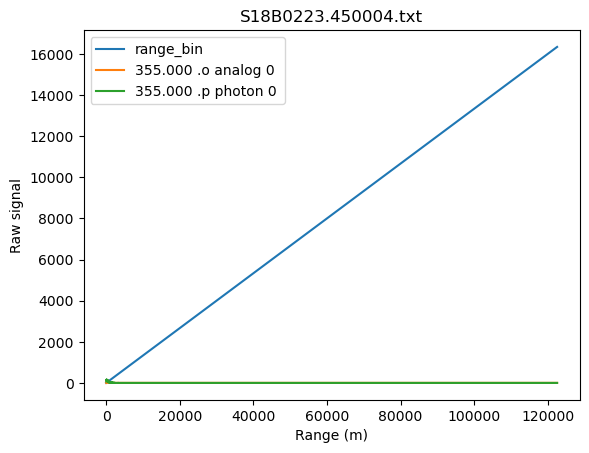

In [ ]:
usc_profile.plot(x="range_m")
plt.xlabel("Range (m)")
plt.ylabel("Raw signal")
plt.title(usc_meta["file_name"])
plt.show()

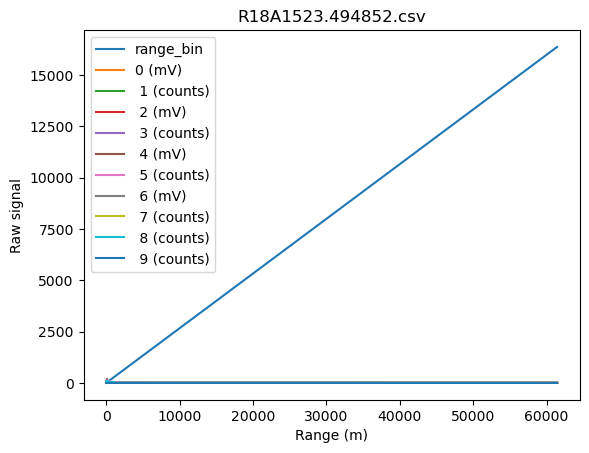

In [11]:
uiuc_profile.plot(x="range_m")
plt.xlabel("Range (m)")
plt.ylabel("Raw signal")
plt.title(uiuc_meta["file_name"])
plt.show()

# Plotting More Profiles
Now I want to plot a few more profiles from each dataset to make sure things look as expected. 

Plotting all USC files...
Number of USC files: 51


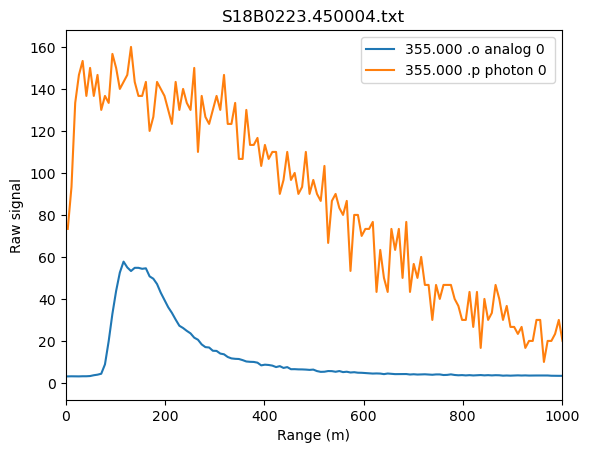

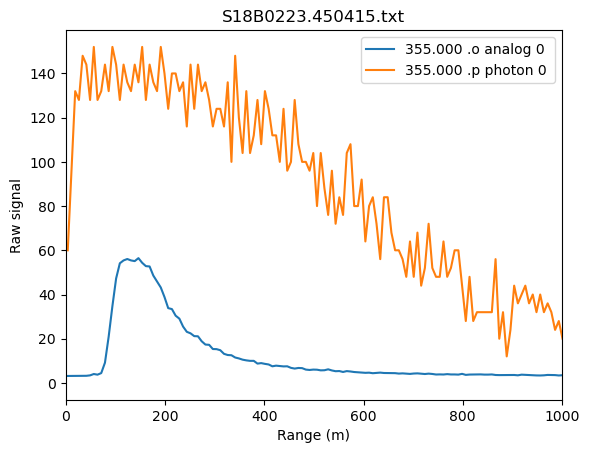

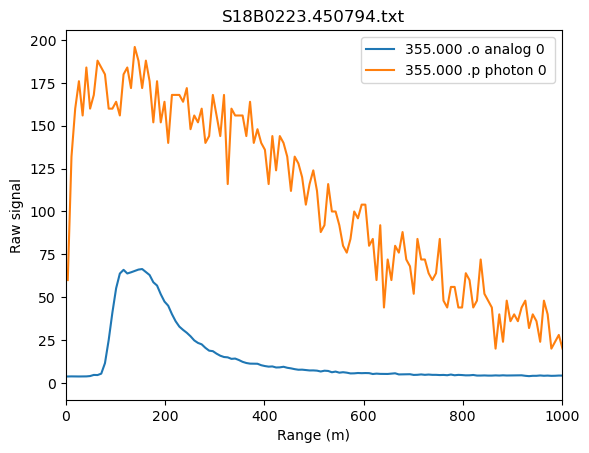

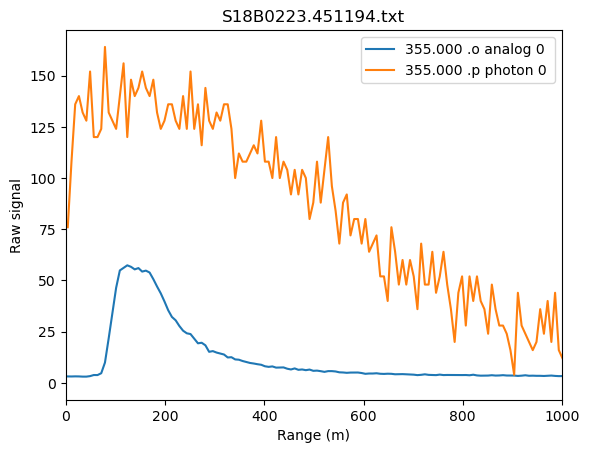

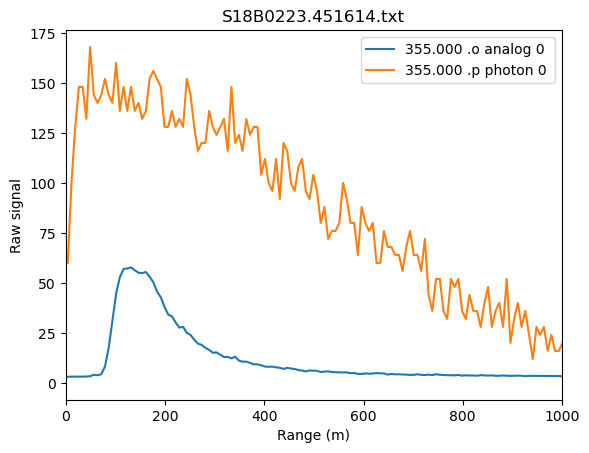

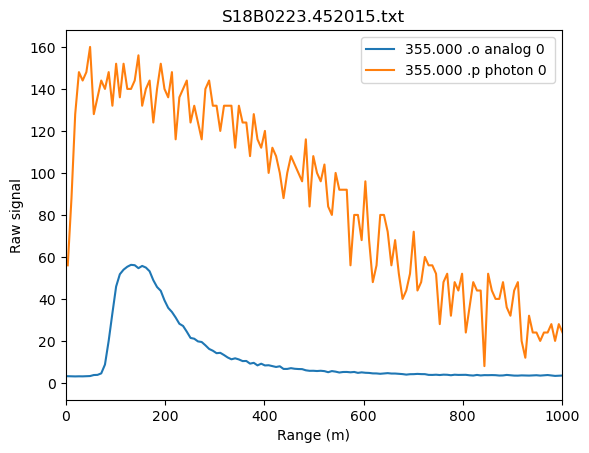

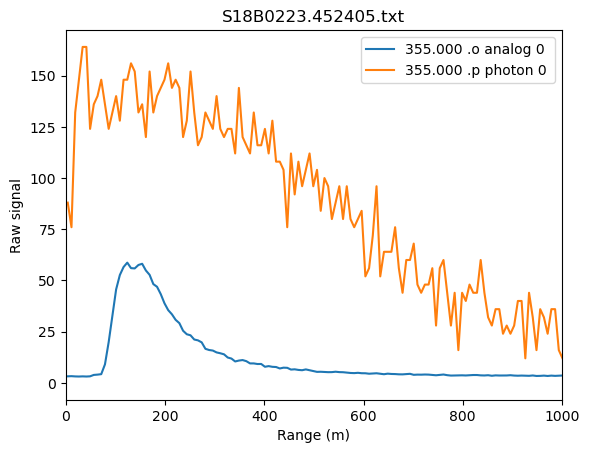

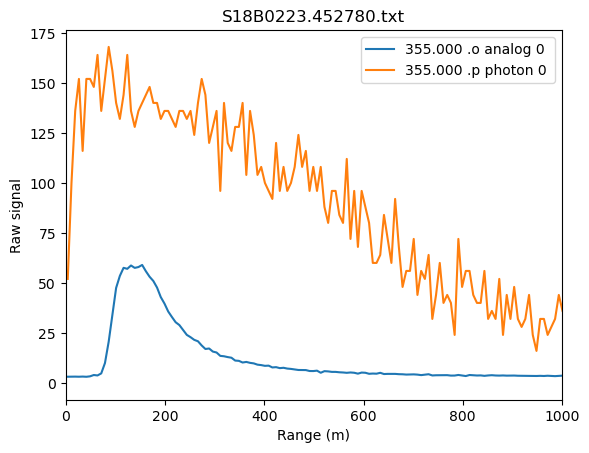

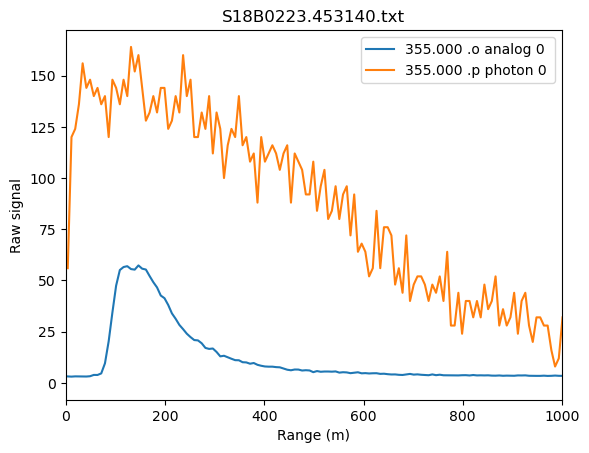

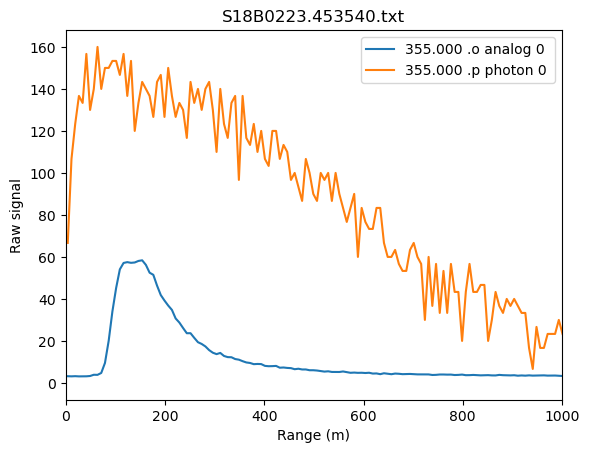

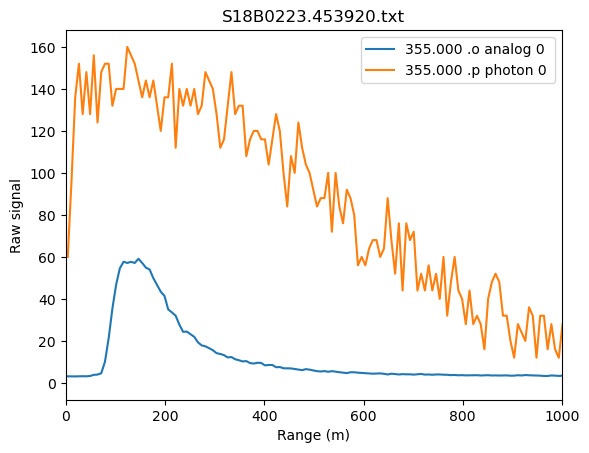

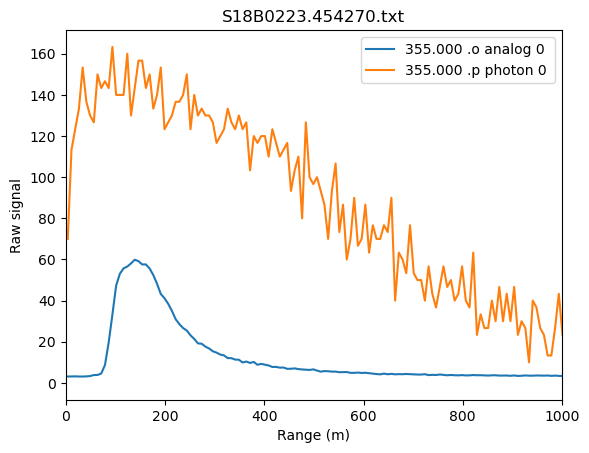

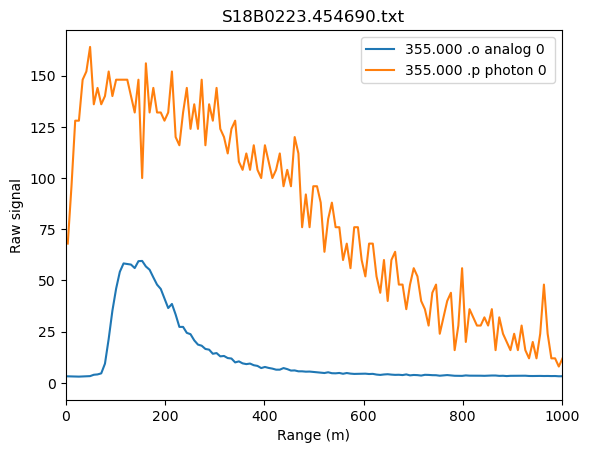

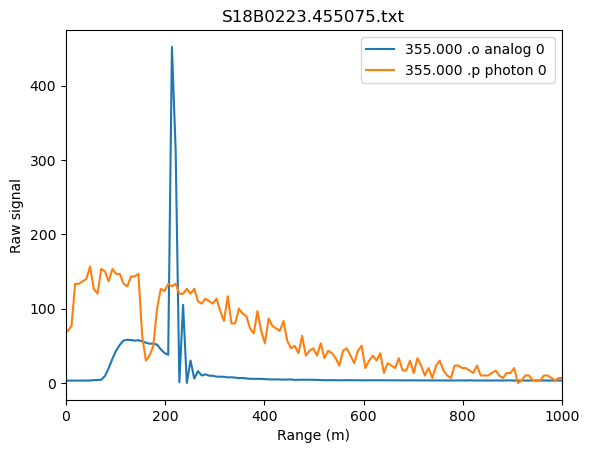

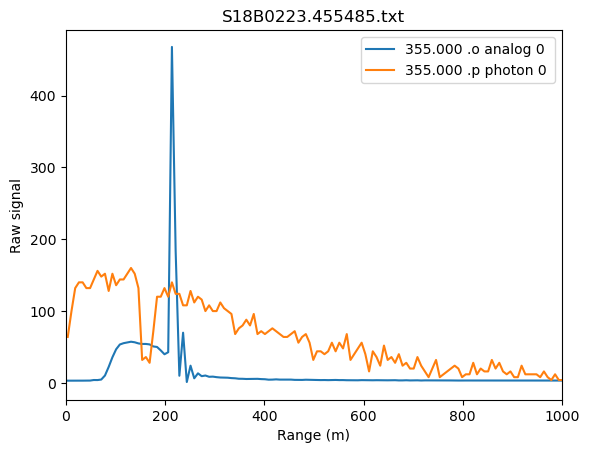

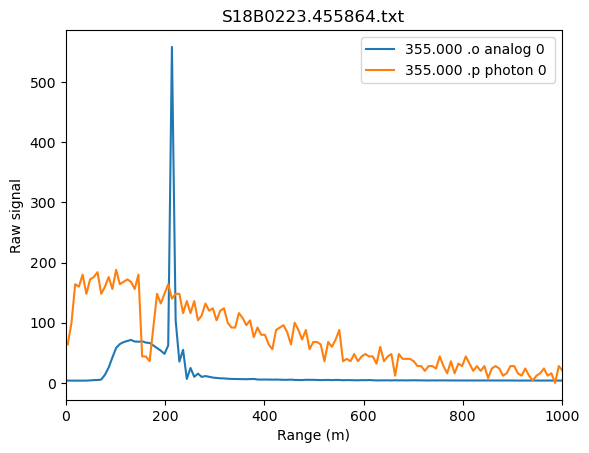

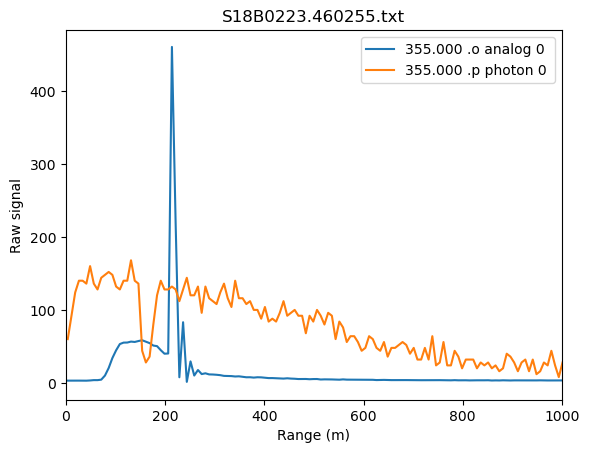

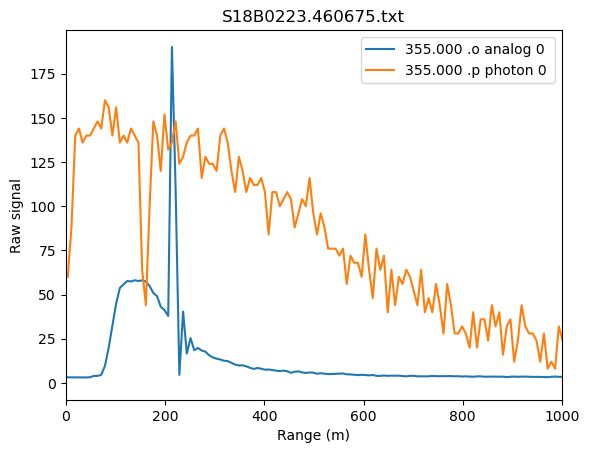

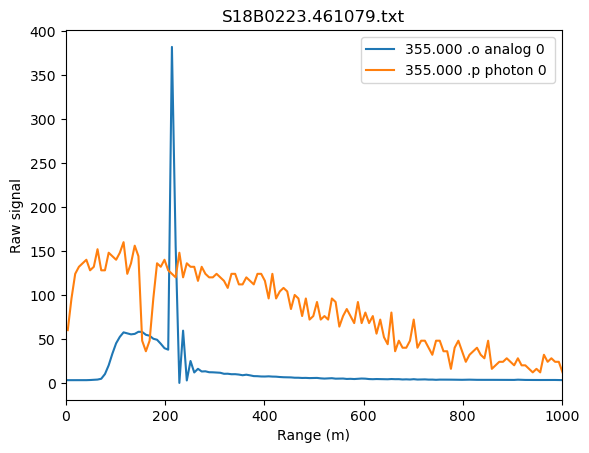

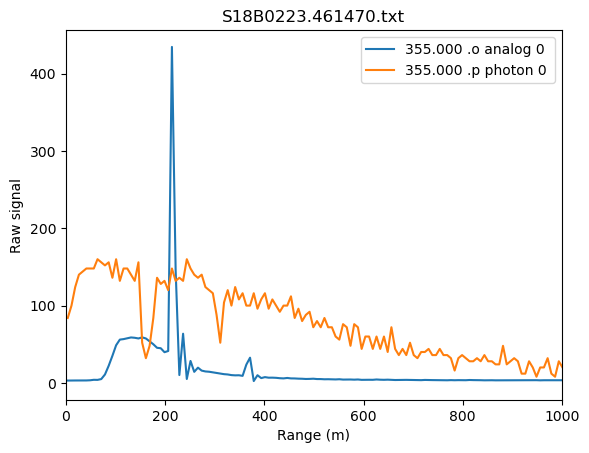

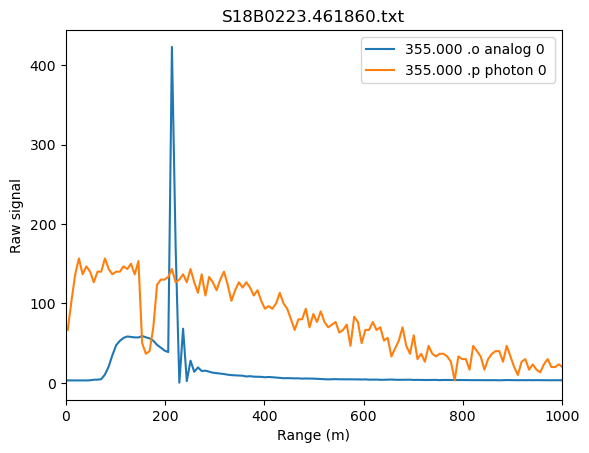

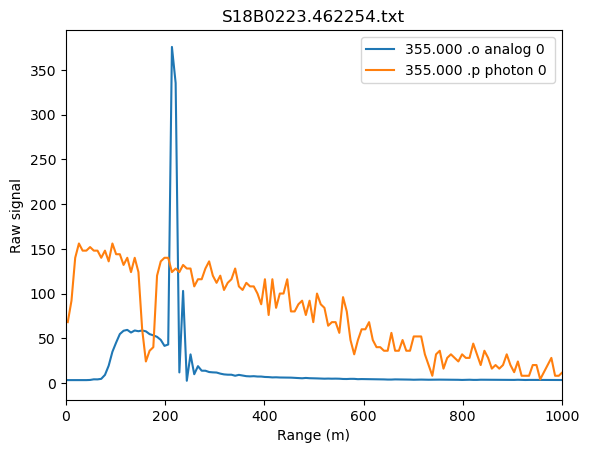

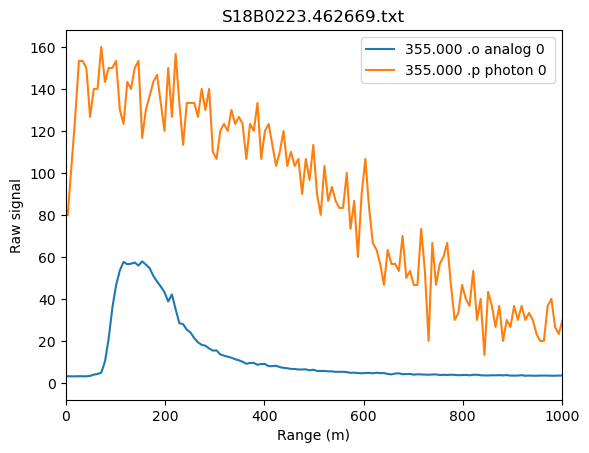

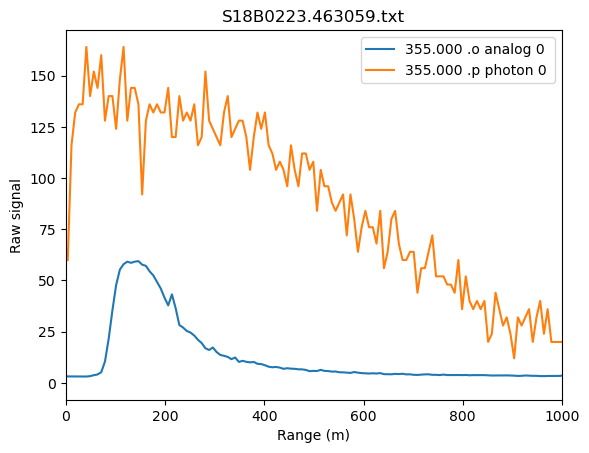

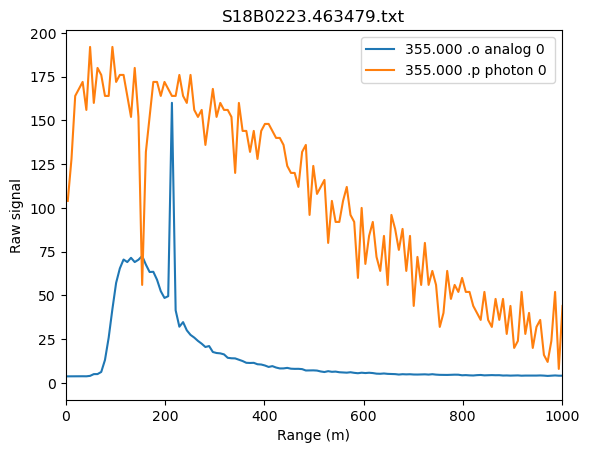

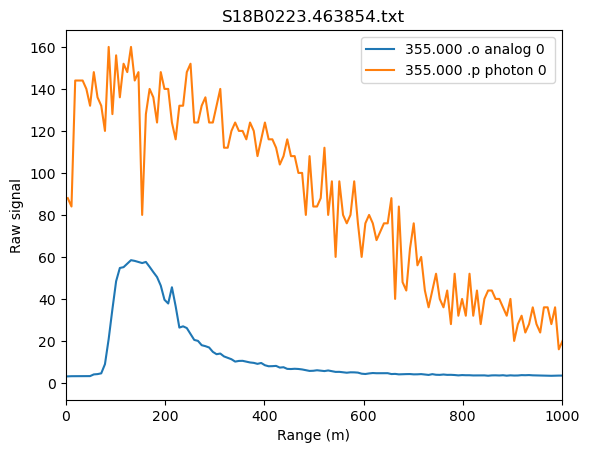

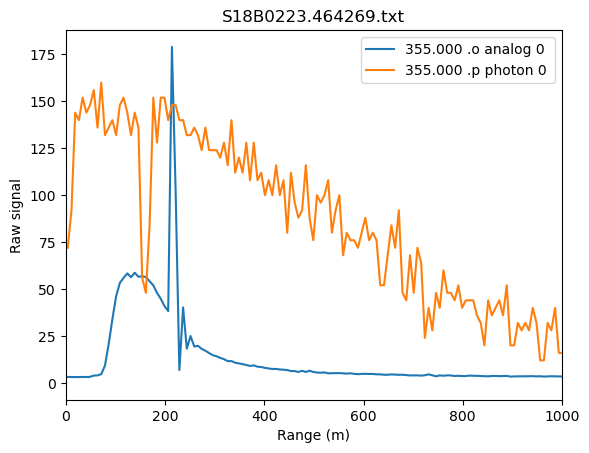

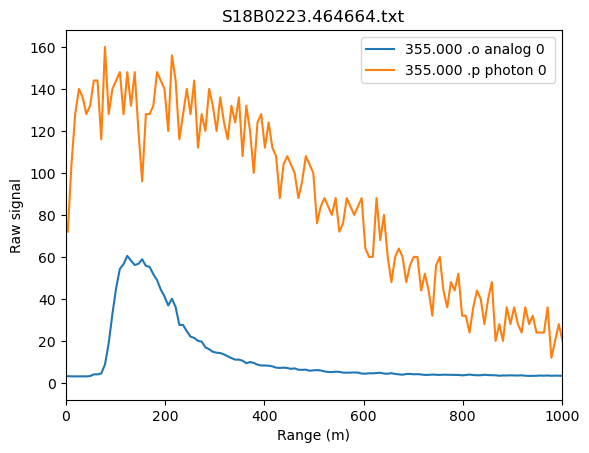

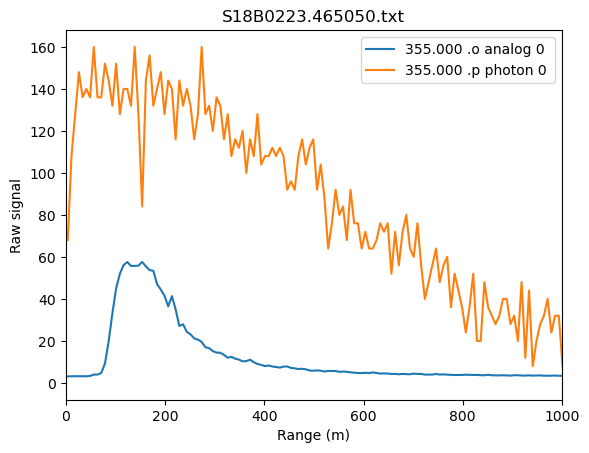

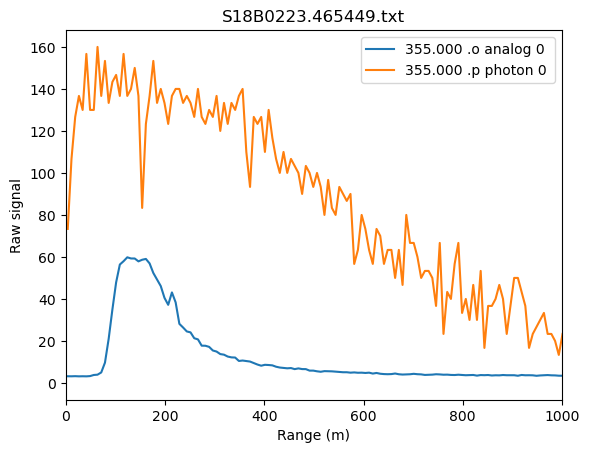

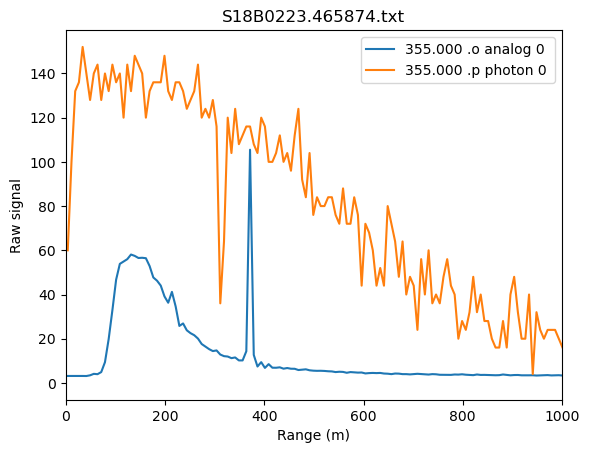

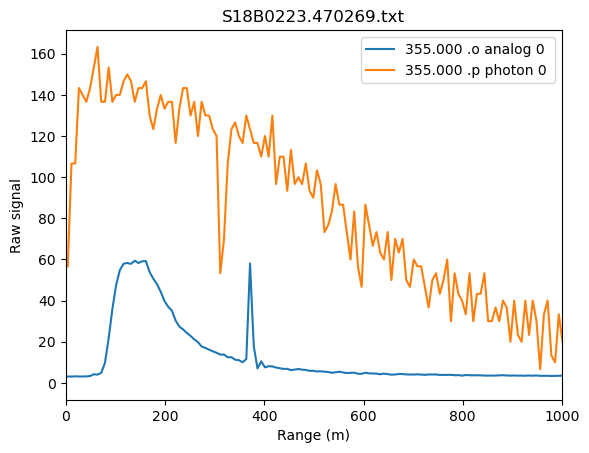

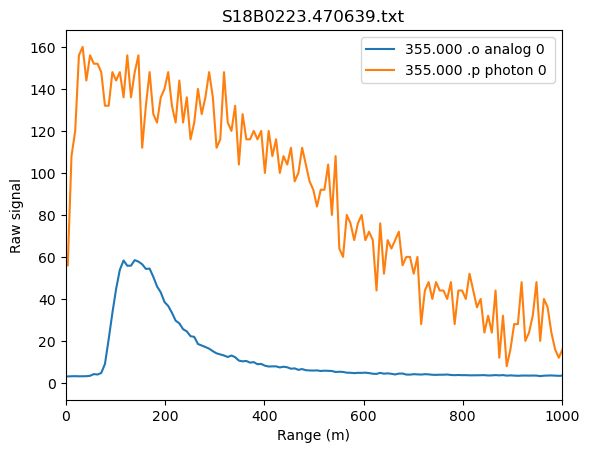

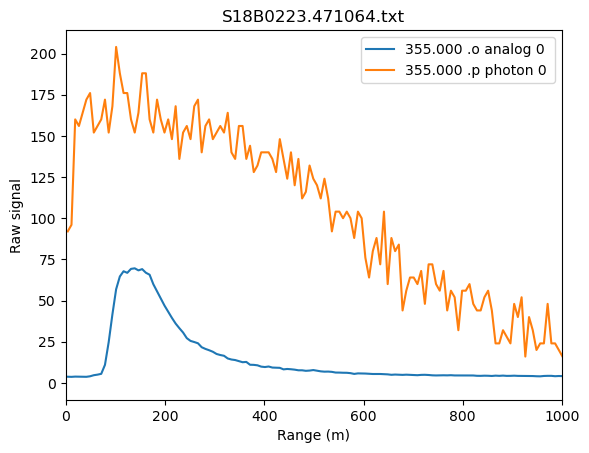

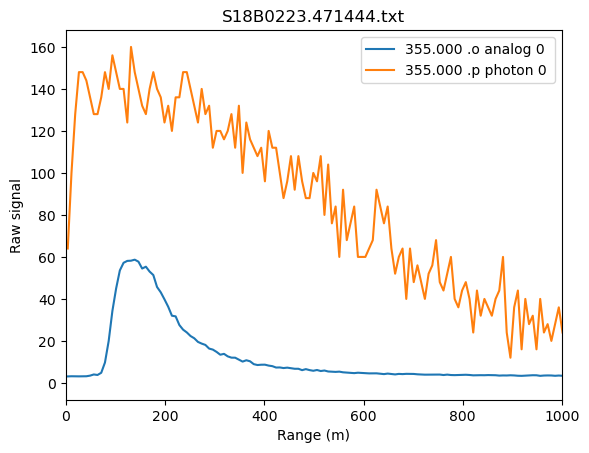

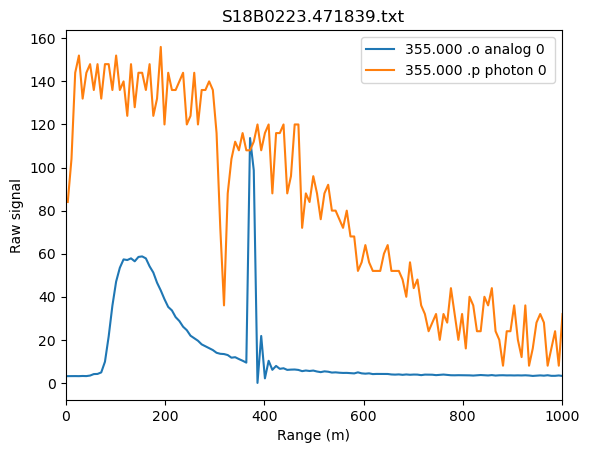

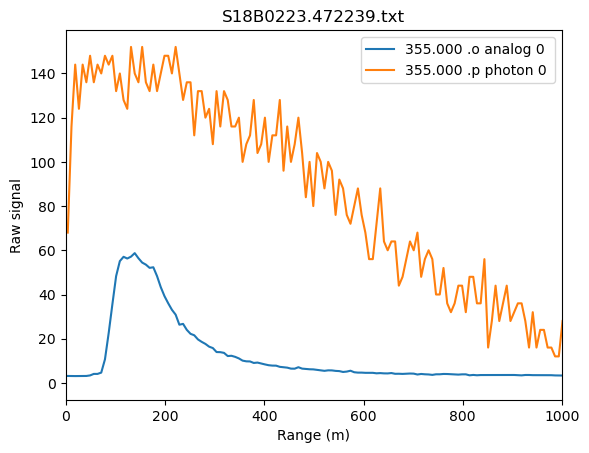

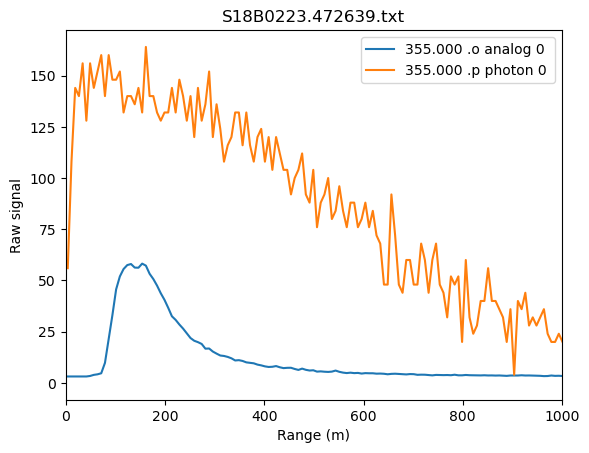

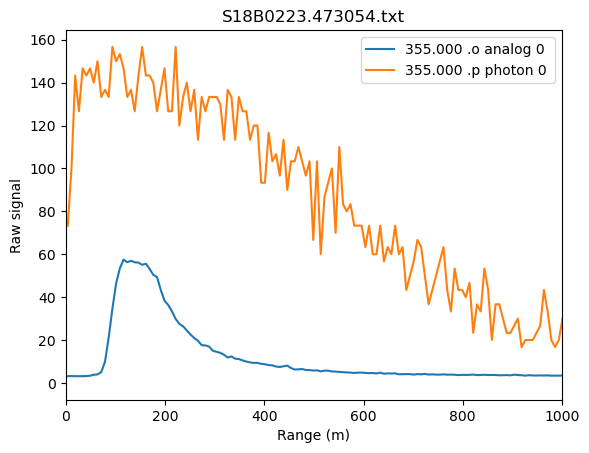

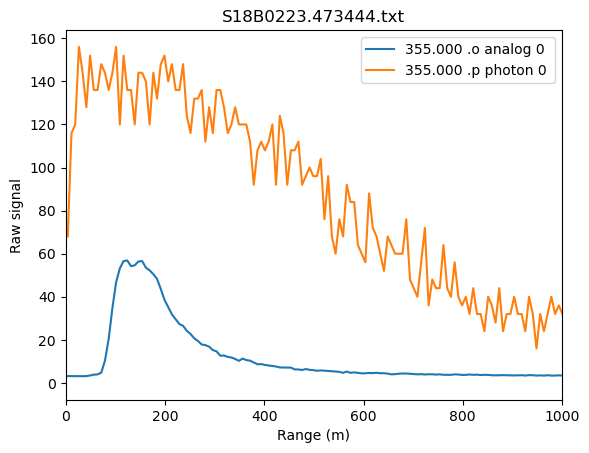

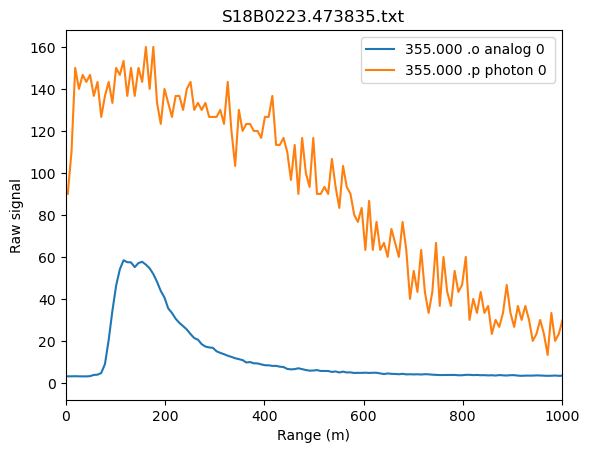

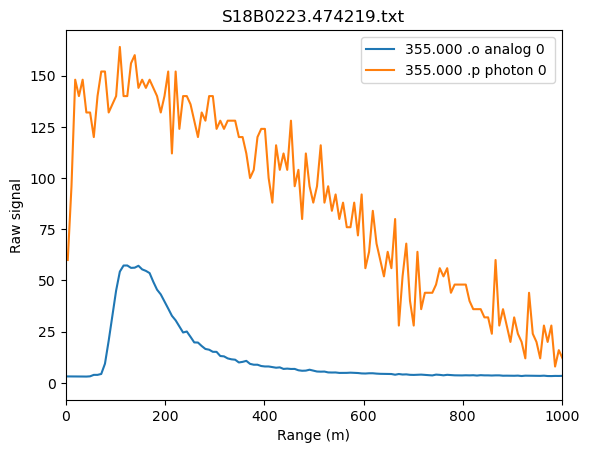

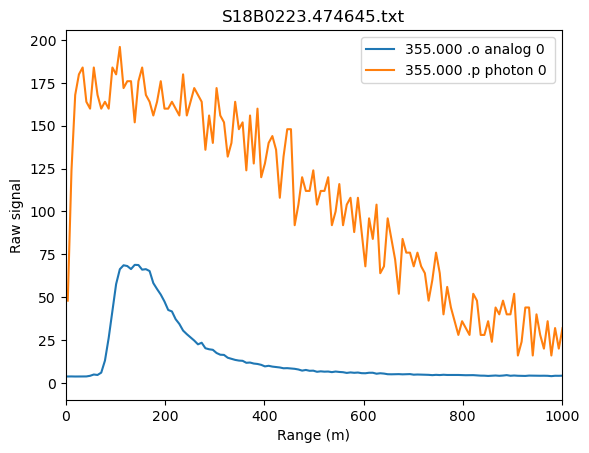

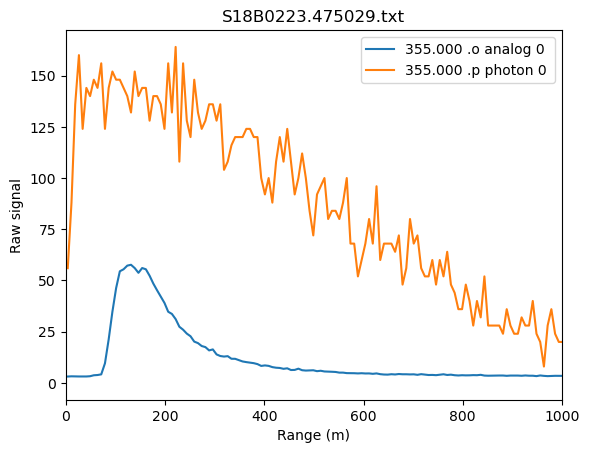

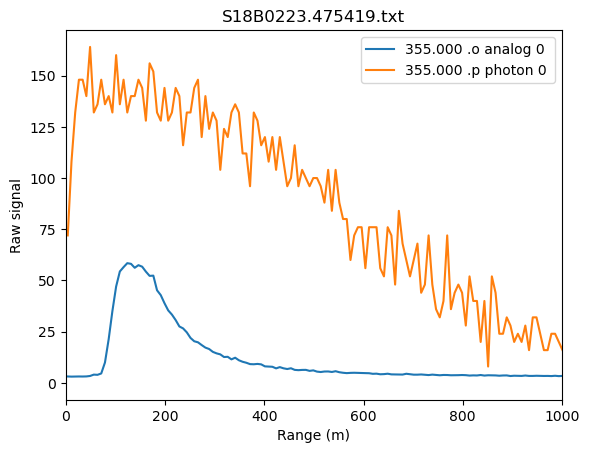

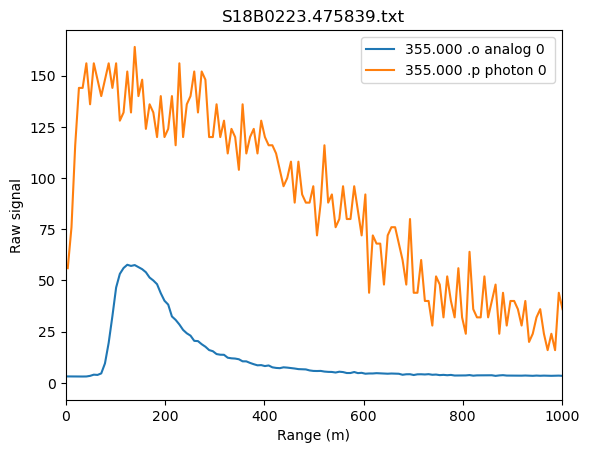

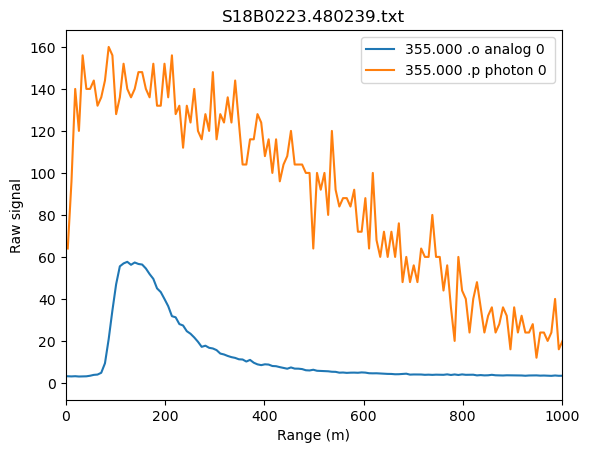

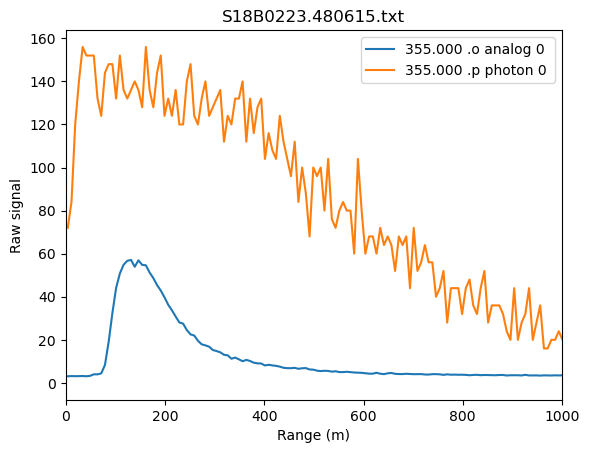

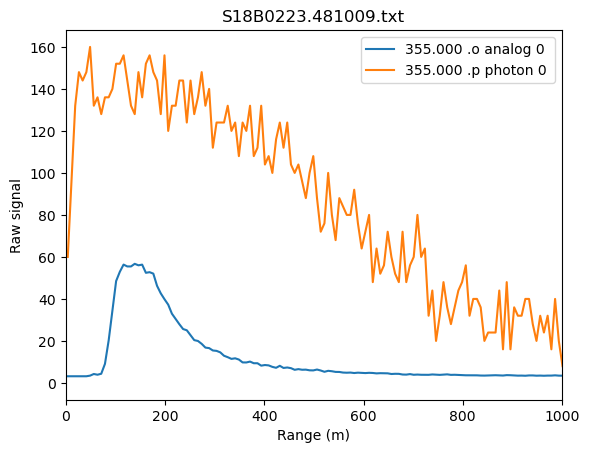

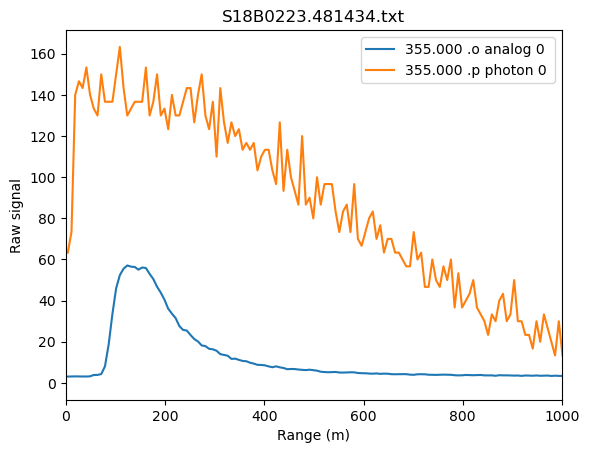

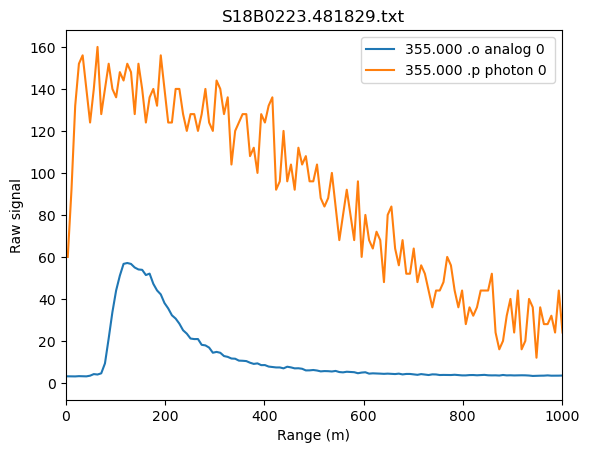

In [24]:
print("Plotting all USC files...")
print(f'Number of USC files: {len(usc_files)}')
for file in usc_files:
    meta, profile = read_lidar_file(file, 'USC', 6)
    # profile.plot(x="range_m")
    profile.drop(columns=["range_bin"]).plot(x="range_m")
    plt.xlim(0, 1000) # we know we are limited on space, so let's limit the x-axis to 1000 m

    plt.xlabel("Range (m)")
    plt.ylabel("Raw signal")
    plt.title(meta["file_name"])
    plt.show()

Plotting all selected UIUC files...
Number of UIUC files: 14


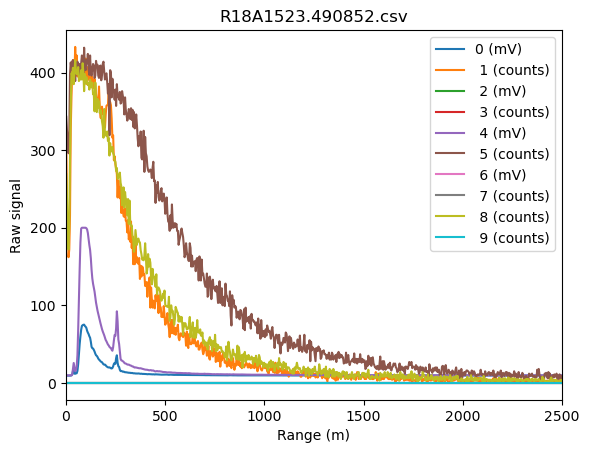

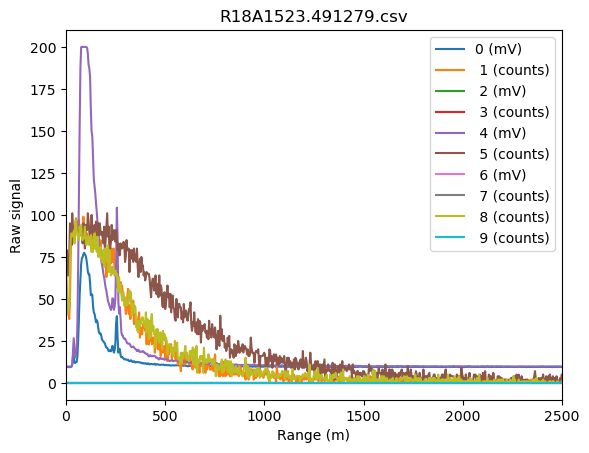

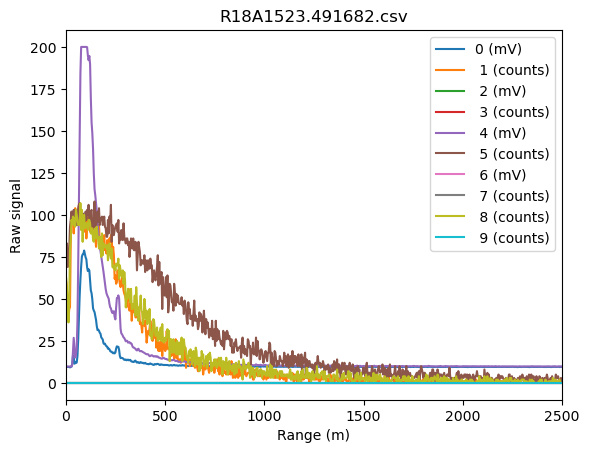

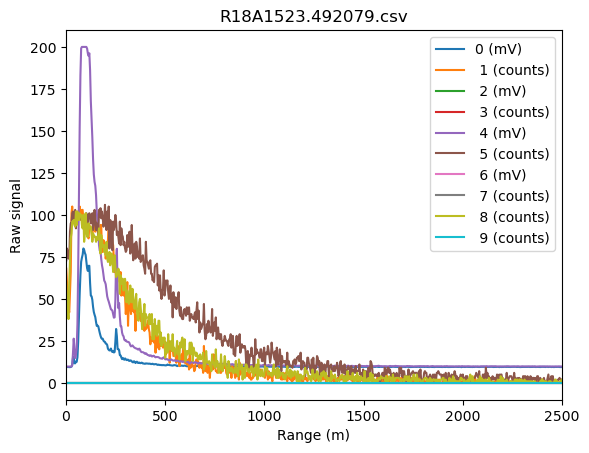

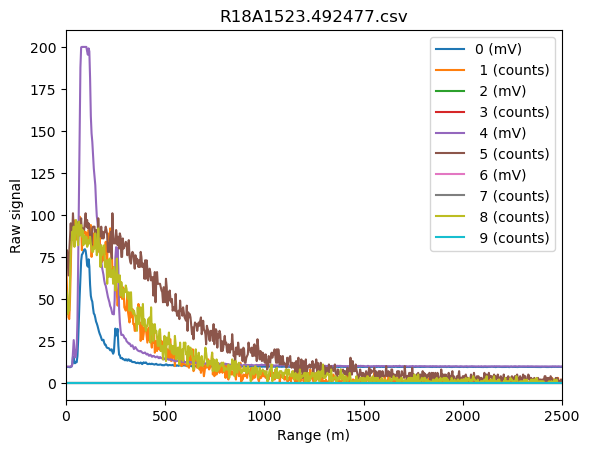

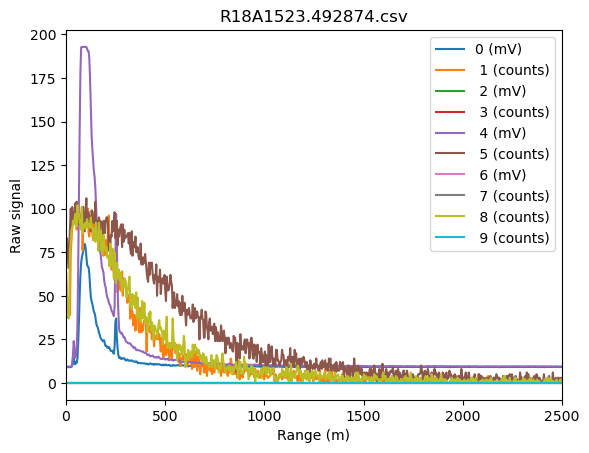

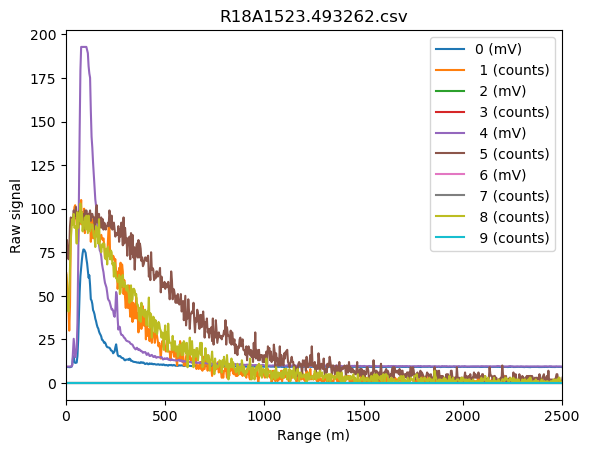

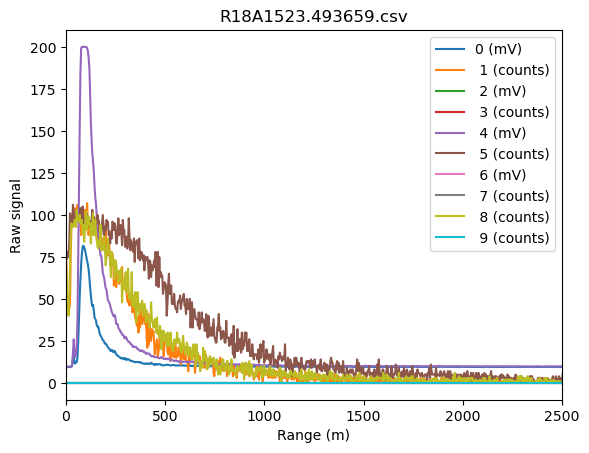

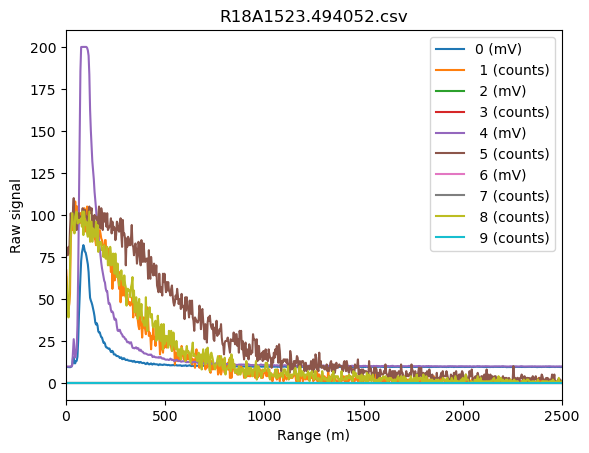

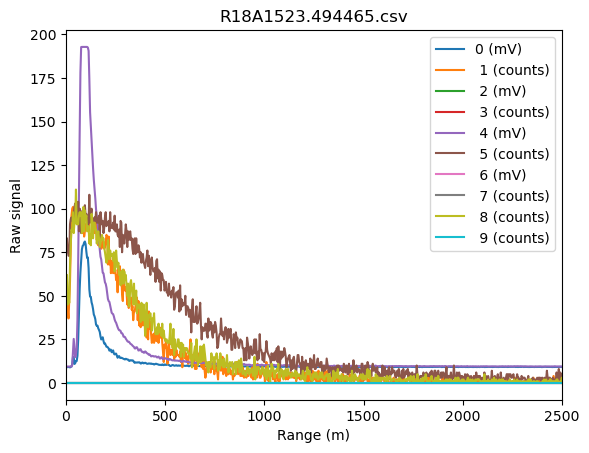

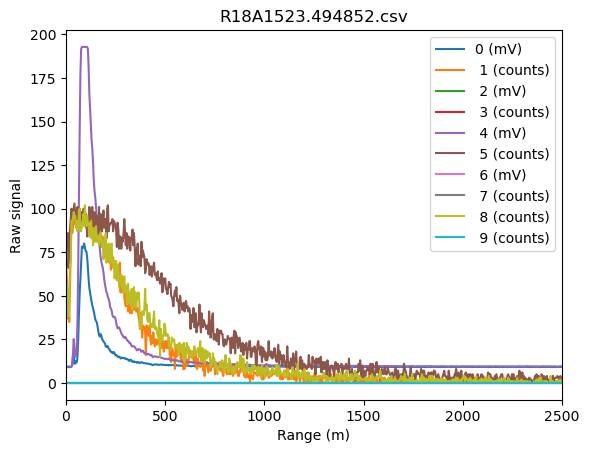

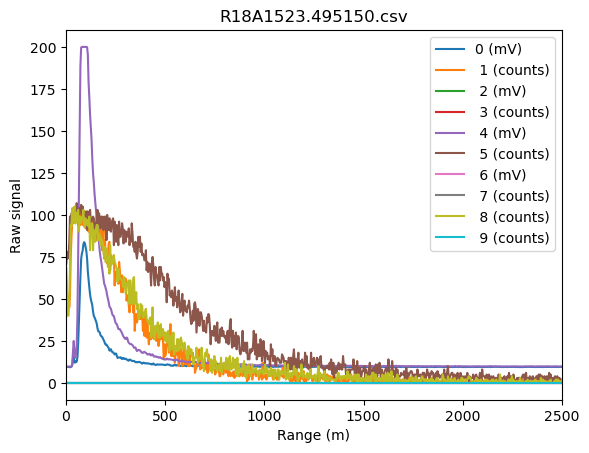

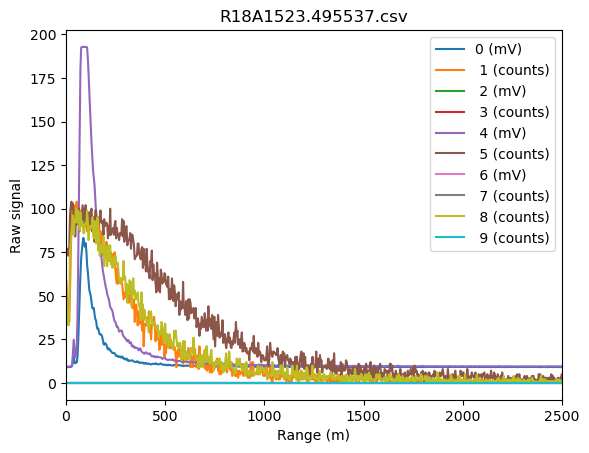

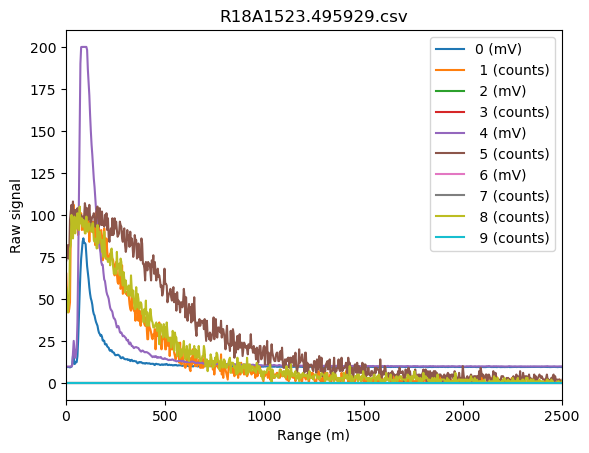

,range_bin,range_m,0 (mV),1 (counts),2 (mV),3 (counts),4 (mV),5 (counts),6 (mV),7 (counts),8 (counts),9 (counts)
count,14.0,14.0,14.000000,14.000000,14.0,14.0,14.000000,14.000000,14.0,14.0,14.000000,14.0
mean,8189.5,30712.5,9.475011,0.777237,0.0,0.0,9.987770,1.380843,0.0,0.0,0.850824,0.0
std,0.0,0.0,0.176765,0.534450,0.0,0.0,0.181630,0.944298,0.0,0.0,0.582165,0.0
min,8189.5,30712.5,9.227575,0.598413,0.0,0.0,9.748154,1.053053,0.0,0.0,0.642918,0.0
25%,8189.5,30712.5,9.255087,0.624130,0.0,0.0,9.757030,1.116819,0.0,0.0,0.690110,0.0
50%,8189.5,30712.5,9.593278,0.639286,0.0,0.0,10.108982,1.134829,0.0,0.0,0.701832,0.0
75%,8189.5,30712.5,9.606724,0.653327,0.0,0.0,10.122060,1.163324,0.0,0.0,0.715461,0.0
max,8189.5,30712.5,9.619636,2.632906,0.0,0.0,10.128540,4.659096,0.0,0.0,2.871734,0.0


In [37]:
print("Plotting all selected UIUC files...")
print(f'Number of UIUC files: {len(uiuc_files)}')

means= pd.DataFrame()
for file in uiuc_files:
    meta, profile = read_lidar_file(file, 'UIUC', 14)
    # profile.plot(x="range_m")
    profile.drop(columns=["range_bin"]).plot(x="range_m")
    
    # we know we are limited on space
    # , so let's limit the x-axis to 2500 m
    plt.xlim(0, 2500) 
    
    plt.xlabel("Range (m)")
    plt.ylabel("Raw signal")
    plt.title(meta["file_name"])
    plt.show()
    # add the mean of the profile to the means dataframe
    means = pd.concat([means, profile.mean().to_frame().T], ignore_index=True)

means.describe()